# Brain age prediction on MS data (smoothed baseline scans)

## Imports and paths

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pyreadstat

# fastMONAI / fastai / MONAI
from fastMONAI.vision_all import *
from fastai.learner import Learner
from fastai.losses import L1LossFlat
from fastai.metrics import mae
from monai.networks.nets import Regressor

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Root directory for thesis project
ms_root = Path("/hus/home/aaasen/Master_thesis")

image_dir = ms_root / "VBM_project_MS" / "T1_scans"

# Metadata file (participants / clinical info)
ms_participants_path = ms_root / "Metadata_OFAMS" / "follow_up_info.csv"


# Path til edss.sav
edss_path = Path("/hus/home/aaasen/Master_thesis/Metadata_OFAMS/edss.sav")

## Load MS metadata

In [3]:
df_part = pd.read_csv(ms_participants_path)
df_part.head()

,Unnamed: 0,Patnr,Sex_OFAMS10,Age_BL_OFAMS,Age_OFAMS10,EDSS_score_10
0,1,101,1.0,35.0,47.0,2
1,2,103,0.0,24.0,36.0,1
2,3,104,1.0,48.0,59.0,"1,5"
3,4,201,0.0,50.0,62.0,2
4,5,202,1.0,31.0,43.0,0


In [4]:
df_part.dtypes

Unnamed: 0         int64
Patnr              int64
Sex_OFAMS10      float64
Age_BL_OFAMS     float64
Age_OFAMS10      float64
EDSS_score_10     object
dtype: object

In [5]:
df_part = df_part.rename(columns={
    'Patnr': 'participant_id',
    'Sex_OFAMS10': 'sex',
    'Age_BL_OFAMS': 'age_BL'})

df_part = df_part.drop(columns=["Unnamed: 0"])
df_part = df_part.drop(columns=["Age_OFAMS10"])
df_part = df_part.drop(columns=["EDSS_score_10"])
df_part["sex"] = df_part["sex"].map({0: "M", 1: "F"}) # 1=female, 0=male

In [6]:
df_part.head()

,participant_id,sex,age_BL
0,101,F,35.0
1,103,M,24.0
2,104,F,48.0
3,201,M,50.0
4,202,F,31.0


In [7]:
df_part.dtypes

participant_id      int64
sex                object
age_BL            float64
dtype: object

## Load EDSS data

In [8]:
edss_df, meta = pyreadstat.read_sav(edss_path)

edss_df.head()

,Patnr,BL_EDSSscore,M6_EDSSscore,M12_EDSSscore,M18_EDSSscore,M24_EDSSscore
0,101.0,1.5,2.0,2.0,2.0,2.0
1,103.0,2.5,1.0,1.0,1.0,0.0
2,104.0,1.5,1.5,2.0,1.5,1.5
3,201.0,1.5,2.5,2.5,2.5,2.5
4,202.0,1.0,1.0,1.0,0.0,0.0


In [9]:
edss_baseline = edss_df[["Patnr", "BL_EDSSscore"]].copy()

# Gi kolonnen samme navn som i df_part
edss_baseline = edss_baseline.rename(columns={
    "Patnr": "participant_id",
    "BL_EDSSscore": "EDSS_BL"
})

edss_baseline.head()

,participant_id,EDSS_BL
0,101.0,1.5
1,103.0,2.5
2,104.0,1.5
3,201.0,1.5
4,202.0,1.0


In [10]:
edss_baseline["participant_id"] = edss_baseline["participant_id"].astype(int)

In [11]:
edss_baseline.dtypes

participant_id      int64
EDSS_BL           float64
dtype: object

In [12]:
df_part = df_part.merge(
    edss_baseline,
    on="participant_id",
    how="left"
)

print("Number with baseline EDSS:", df_part["EDSS_BL"].notna().sum())
df_part.head()

Number with baseline EDSS: 88


,participant_id,sex,age_BL,EDSS_BL
0,101,F,35.0,1.5
1,103,M,24.0,2.5
2,104,F,48.0,1.5
3,201,M,50.0,1.5
4,202,F,31.0,1.0


## Remove subjects with missing age

In [13]:
# Removing rows with NaN values in age_BL (age at baseline)
df_part = df_part.dropna(subset=["age_BL"])
df_part.head()

,participant_id,sex,age_BL,EDSS_BL
0,101,F,35.0,1.5
1,103,M,24.0,2.5
2,104,F,48.0,1.5
3,201,M,50.0,1.5
4,202,F,31.0,1.0


In [14]:
min_age_new = df_part["age_BL"].min()
max_age_new = df_part["age_BL"].max()

print("Ages at baseline:")
print(f"Min age: {min_age_new}")
print(f"Max age: {max_age_new}")

Ages at baseline:
Min age: 19.0
Max age: 58.0


## Build dataframe linking images to subject metadata

In [15]:
from pathlib import Path
import pandas as pd

rows = []

# Finn alle baseline step4_warped-filer rekursivt
# Bytt pattern hvis asymmetrifilene dine har annet navn.
image_paths = sorted(image_dir.rglob("baseline/mri/step4_warped/sAI_mwrp1sub-*_ses-baseline_ce-GADOLINIUM_*_affine.nii*"))

print("Found image files:", len(image_paths))
if len(image_paths) > 0:
    print("Example:", image_paths[0])

for p in image_paths:
    fname = p.name

    # 1) Prøv å hente ID fra filnavn: "...sub-101..."
    participant_id = None
    if "sub-" in fname:
        try:
            participant_id = fname.split("sub-")[1].split("_")[0]
        except IndexError:
            participant_id = None

    # 2) Fallback: hent ID fra mappestruktur: .../T1_scans/101/baseline/...
    if participant_id is None:
        # p.parts inneholder alle mappenavn i stien
        # Finn indeksen til "T1_scans" og ta neste element (= subject folder, f.eks. "101")
        parts = p.parts
        if "T1_scans" in parts:
            i = parts.index("T1_scans")
            if i + 1 < len(parts):
                participant_id = parts[i + 1]

    if participant_id is None:
        print("Could not parse subject ID from:", p)
        continue

    # Match metadata
    match = df_part[df_part["participant_id"].astype(str) == str(participant_id)]

    if len(match) == 1:
        rows.append({
            "image_path": str(p),
            "participant_id": str(participant_id),
            "sex": match["sex"].values[0],
            "age_BL": match["age_BL"].values[0],
            "EDSS_BL": match["EDSS_BL"].values[0],
        })
    else:
        print("Metadata not found (or not unique) for subject:", participant_id, "matches:", len(match))

df_ms = pd.DataFrame(rows)

print("Number of MS scans:", len(df_ms))
df_ms.head()

Found image files: 87
Example: /hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/101/baseline/mri/step4_warped/sAI_mwrp1sub-101_ses-baseline_ce-GADOLINIUM_FLASH_affine.nii
Metadata not found (or not unique) for subject: 102 matches: 0
Metadata not found (or not unique) for subject: 1408 matches: 0
Metadata not found (or not unique) for subject: 403 matches: 0
Metadata not found (or not unique) for subject: 504 matches: 0
Number of MS scans: 83


,image_path,participant_id,sex,age_BL,EDSS_BL
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/101/baseline/mri/step4_warped/sAI_mwrp1sub-101_ses-baseline_ce-GADOLINIUM_FLASH_affine.nii,101,F,35.0,1.5
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/103/baseline/mri/step4_warped/sAI_mwrp1sub-103_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,103,M,24.0,2.5
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/104/baseline/mri/step4_warped/sAI_mwrp1sub-104_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,104,F,48.0,1.5
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1101/baseline/mri/step4_warped/sAI_mwrp1sub-1101_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.0,2.0
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1102/baseline/mri/step4_warped/sAI_mwrp1sub-1102_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.0,1.5


## Build DataBlock

In [16]:
import pickle
from pathlib import Path

# Path til lagrede preprocessing-parametere
preproc_path = Path("/hus/home/aaasen/Master_thesis/smoothed_model/smoothed_preproc_params.pkl")

with open(preproc_path, "rb") as f:
    preproc = pickle.load(f)

resample = preproc["resample"]
reorder  = preproc["reorder"]

print("Preprocessing parameters loaded successfully.")
print("Resample:", resample)
print("Reorder:", reorder)

Preprocessing parameters loaded successfully.
Resample: [1.5, 1.5, 1.5]
Reorder: False


In [17]:
# Identical to baseline_train
in_shape = [1, 128, 160, 128]

item_tfms = [ZNormalization(), PadOrCrop(in_shape[1:])]

In [18]:
dblock = MedDataBlock(
    blocks=(ImageBlock(cls=MedImage), RegressionBlock),
    splitter=None,  # no splitting for inference
    get_x=ColReader("image_path"),
    get_y=ColReader("age_BL"),  # used only for analysis
    item_tfms=item_tfms,
    apply_reorder=reorder,
    target_spacing=resample
)

dls = dblock.dataloaders(df_ms, bs=4)

## Load model

In [19]:
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2
)

In [20]:
learn = Learner(
    dls,
    model,
    loss_func=L1LossFlat(), 
    metrics=[mae],
)

from pathlib import Path

learn.path = Path("/hus/home/aaasen/Master_thesis/smoothed_model")
learn.model_dir = ""   # siden filen ligger direkte i mappen

# Load trained weights
learn.load("smoothed_baseline_best")

Saved file doesn't contain an optimizer state.


In [21]:
learn.model.eval()

Regressor(
  (net): Sequential(
    (layer_0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (layer_1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
         

## Brain age predictions and brain age gap

In [22]:
test_dl = dls.test_dl(df_ms, with_labels=True)

In [23]:
preds, targs = learn.get_preds(dl=test_dl) # test = the whole dataset when splitter=None

y_pred = preds.squeeze().cpu().numpy()
y_true = targs.squeeze().cpu().numpy()

df_ms["predicted_age"] = y_pred
df_ms["brain_age_gap"] = y_pred - df_ms["age_BL"]

df_ms.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/101/baseline/mri/step4_warped/sAI_mwrp1sub-101_ses-baseline_ce-GADOLINIUM_FLASH_affine.nii,101,F,35.0,1.5,32.195694,-2.804306
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/103/baseline/mri/step4_warped/sAI_mwrp1sub-103_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,103,M,24.0,2.5,36.474022,12.474022
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/104/baseline/mri/step4_warped/sAI_mwrp1sub-104_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,104,F,48.0,1.5,35.260303,-12.739697
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1101/baseline/mri/step4_warped/sAI_mwrp1sub-1101_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.0,2.0,36.009117,-9.990883
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1102/baseline/mri/step4_warped/sAI_mwrp1sub-1102_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.0,1.5,46.991196,7.991196


## Bias correction

In [24]:
# Load bias correction parameters estimated on train set
a, b = np.load("smoothed_bias_correction_params.npy")
y_pred_bc = (y_pred - b) / a

df_ms["predicted_age_bc"] = (df_ms["predicted_age"] - b) / a
df_ms["brain_age_gap_bc"] = df_ms["predicted_age_bc"] - df_ms["age_BL"]

In [25]:
df_ms.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/101/baseline/mri/step4_warped/sAI_mwrp1sub-101_ses-baseline_ce-GADOLINIUM_FLASH_affine.nii,101,F,35.0,1.5,32.195694,-2.804306,32.905727,-2.094273
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/103/baseline/mri/step4_warped/sAI_mwrp1sub-103_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,103,M,24.0,2.5,36.474022,12.474022,37.120201,13.120201
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/104/baseline/mri/step4_warped/sAI_mwrp1sub-104_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,104,F,48.0,1.5,35.260303,-12.739697,35.924599,-12.075401
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1101/baseline/mri/step4_warped/sAI_mwrp1sub-1101_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.0,2.0,36.009117,-9.990883,36.662235,-9.337765
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1102/baseline/mri/step4_warped/sAI_mwrp1sub-1102_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.0,1.5,46.991196,7.991196,47.480396,8.480396


## Prediction results

In [26]:
print(df_ms[["participant_id", "sex", "age_BL", "predicted_age", "brain_age_gap", "predicted_age_bc", "brain_age_gap_bc", "EDSS_BL"]].head())
print("N =", len(df_ms))
print("Mean BAG:", df_ms["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_ms["brain_age_gap_bc"].mean())
print("Std BAG:", df_ms["brain_age_gap"].std())
print("Std BAG (bias-corrected):", df_ms["brain_age_gap_bc"].std())

  participant_id sex  age_BL  predicted_age  brain_age_gap  predicted_age_bc  \
0            101   F    35.0      32.195694      -2.804306         32.905727   
1            103   M    24.0      36.474022      12.474022         37.120201   
2            104   F    48.0      35.260303     -12.739697         35.924599   
3           1101   F    46.0      36.009117      -9.990883         36.662235   
4           1102   F    39.0      46.991196       7.991196         47.480396   

   brain_age_gap_bc  EDSS_BL  
0         -2.094273      1.5  
1         13.120201      2.5  
2        -12.075401      1.5  
3         -9.337765      2.0  
4          8.480396      1.5  
N = 83
Mean BAG: 1.5114881446562618
Mean BAG (bias-corrected): 2.101899870906968
Std BAG: 10.341337096234643
Std BAG (bias-corrected): 10.274647585772028


## Quality Control (QC)

### Extreme outliers

Checking if the huge BAG is due to wrongfully done preprocessing, empty image etc. Manually checking these images.

In [27]:
df_ms.sort_values("brain_age_gap", key=lambda x: abs(x), ascending=False).head(5)

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
60,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/705/baseline/mri/step4_warped/sAI_mwrp1sub-705_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,705,F,19.0,1.0,48.036285,29.036285,48.509888,29.509888
22,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1414/baseline/mri/step4_warped/sAI_mwrp1sub-1414_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1414,F,27.0,1.0,55.896469,28.896469,56.252754,29.252754
21,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1413/baseline/mri/step4_warped/sAI_mwrp1sub-1413_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1413,F,26.0,2.0,49.689041,23.689041,50.137978,24.137978
11,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1401/baseline/mri/step4_warped/sAI_mwrp1sub-1401_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1401,F,22.0,2.0,42.618641,20.618641,43.173107,21.173107
16,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1406/baseline/mri/step4_warped/sAI_mwrp1sub-1406_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1406,F,25.0,0.0,44.565258,19.565258,45.090668,20.090668


Conclution: Nothing unusual with these asymmetry images.

In [28]:
# checking the input shape
xb, _ = dls.one_batch()
print(xb.shape)

torch.Size([4, 1, 128, 160, 128])


### Visualizing the 10 subjects with the largest and smallest BAG

Checking the visualizations if anything looks unusual.

In [29]:
# Top 10 best and worst predictions (abs bias-corrected error)
best_cases = df_ms.sort_values("brain_age_gap").head(10)
worst_cases = df_ms.sort_values("brain_age_gap", ascending=False).head(10)

In [30]:
best_cases[
    ["participant_id", "sex", "age_BL", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_BL"]
    ]

,participant_id,sex,age_BL,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_BL
53,603,F,54.0,37.496105,38.127029,-16.503895,-15.872971,2.5
71,808,M,50.0,33.823944,34.509678,-16.176056,-15.490322,1.5
69,805,F,45.0,29.974493,30.717680,-15.025507,-14.282320,2.5
79,901,NaN,52.0,37.438438,38.070221,-14.561562,-13.929779,1.0
31,206,M,50.0,36.757343,37.399292,-13.242657,-12.600708,3.5
35,210,F,51.0,38.075596,38.697868,-12.924404,-12.302132,2.5
2,104,F,48.0,35.260303,35.924599,-12.739697,-12.075401,1.5
8,1201,NaN,43.0,30.488342,31.223862,-12.511658,-11.776138,1.5
24,1503,M,45.0,33.248234,33.942558,-11.751766,-11.057442,1.5
82,904,F,46.0,34.258602,34.937847,-11.741398,-11.062153,1.0


In [31]:
worst_cases[
    ["participant_id", "sex", "age_BL", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_BL"]
    ]

ERROR! Session/line number was not unique in database. History logging moved to new session 19


,participant_id,sex,age_BL,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_BL
60,705,F,19.0,48.036285,48.509888,29.036285,29.509888,1.0
22,1414,F,27.0,55.896469,56.252754,28.896469,29.252754,1.0
21,1413,F,26.0,49.689041,50.137978,23.689041,24.137978,2.0
11,1401,F,22.0,42.618641,43.173107,20.618641,21.173107,2.0
16,1406,F,25.0,44.565258,45.090668,19.565258,20.090668,0.0
13,1403,F,30.0,49.289555,49.744453,19.289555,19.744453,1.0
19,1411,M,38.0,54.013512,54.397900,16.013512,16.397900,2.5
44,303,F,26.0,41.468487,42.040119,15.468487,16.040119,3.5
48,501,F,24.0,38.787392,39.399040,14.787392,15.399040,2.0
55,606,M,33.0,47.516941,47.998295,14.516941,14.998295,3.5


In [32]:
def show_asymmetry_image(image_path, title=None, slice_idx=None):
    img = nib.load(image_path).get_fdata()

    # Default: mid axial slice
    if slice_idx is None:
        slice_idx = img.shape[2] // 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img[:, :, slice_idx].T, cmap="bwr", origin="lower")
    plt.colorbar(fraction=0.046)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

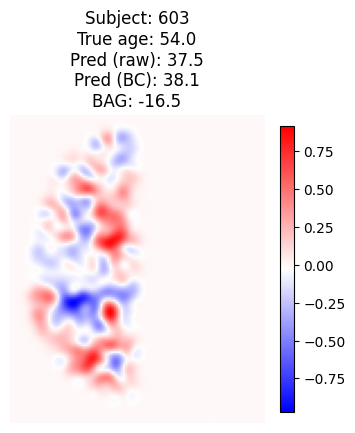

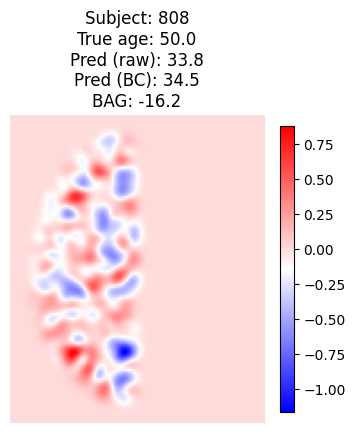

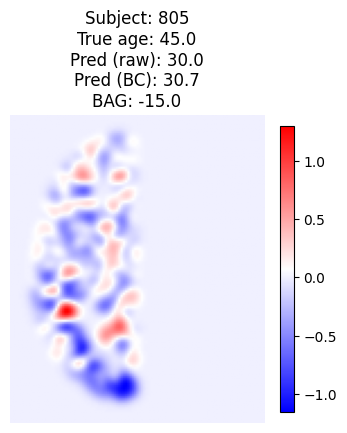

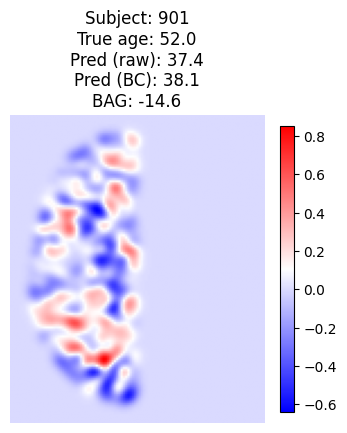

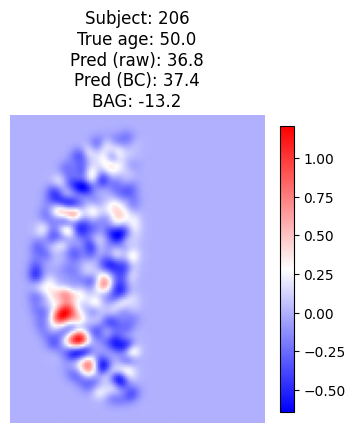

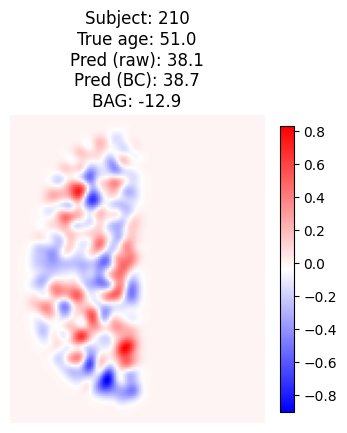

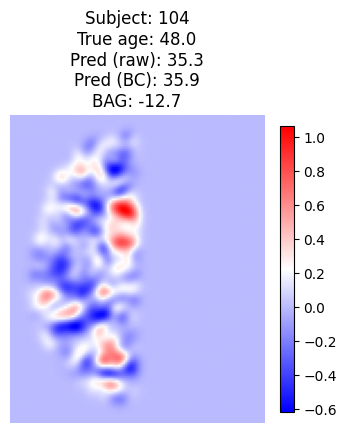

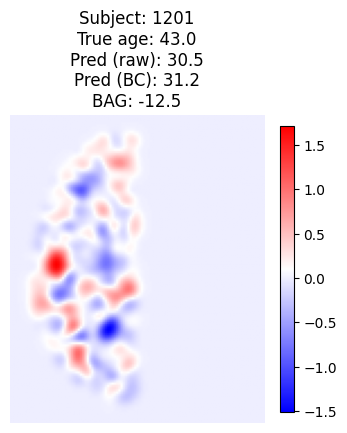

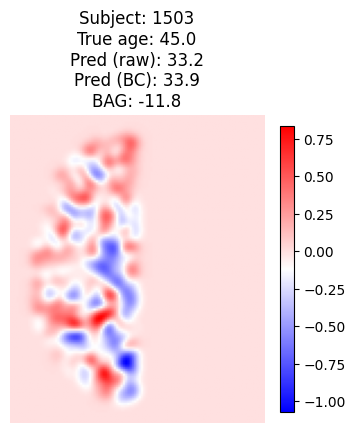

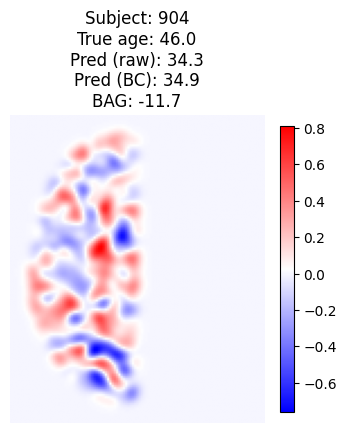

In [33]:
# Best cases sorted after bias-corrected predictions (smallest BAG)
for _, row in best_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_BL']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

# red/positive values: rightward asymmetry
# blue/negative values: leftward asymmetry

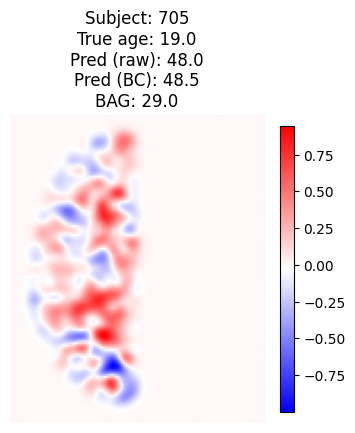

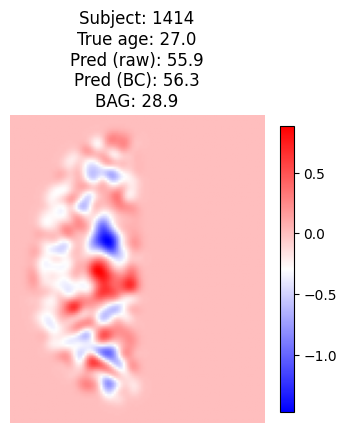

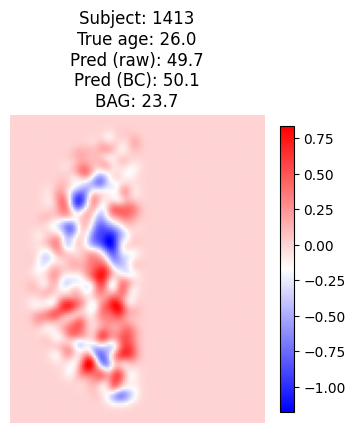

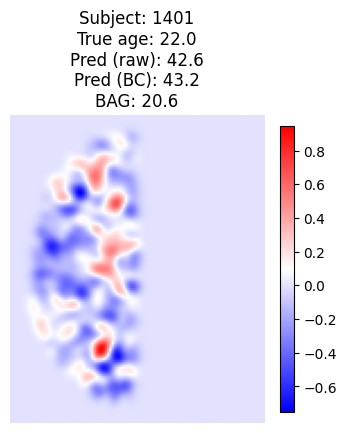

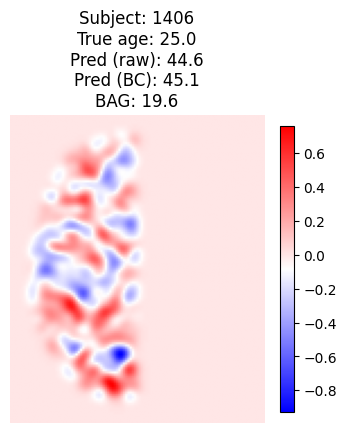

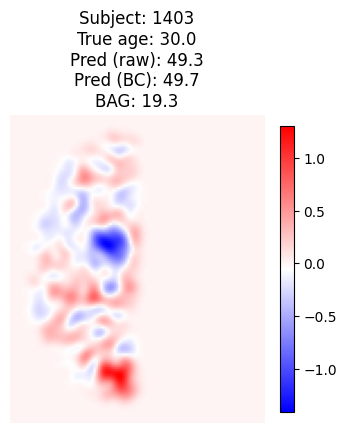

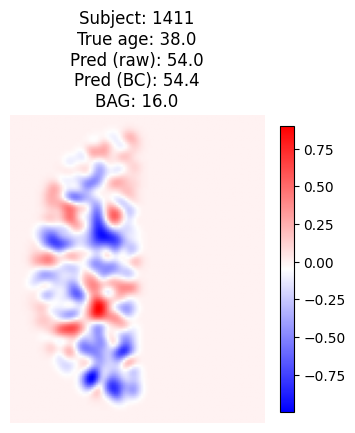

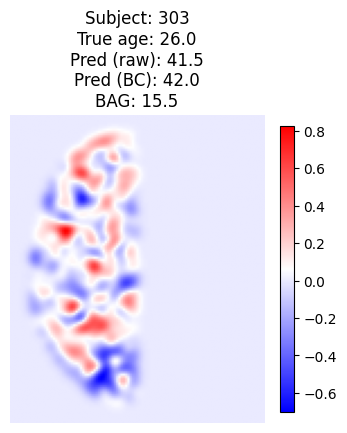

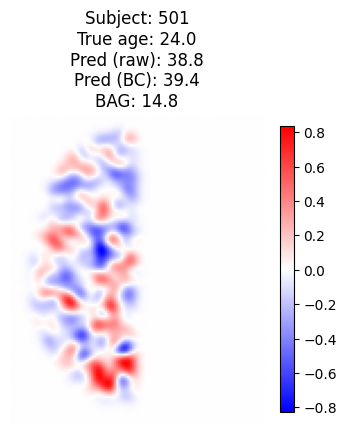

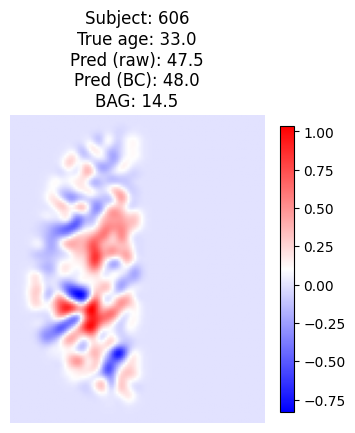

In [34]:
# Worst cases sorted after bias-corrected predictions (largest BAG)
for _, row in worst_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_BL']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

Conclusions: Nothing suspicious.

## Plots

### Predicted age

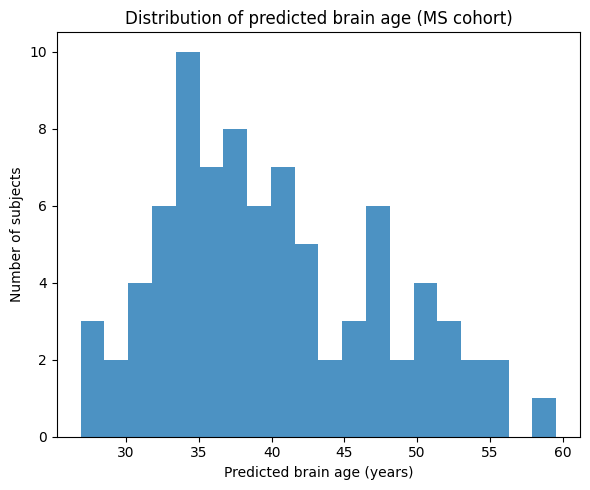

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.hist(df_ms["predicted_age"], bins=20, alpha=0.8)
plt.xlabel("Predicted brain age (years)")
plt.ylabel("Number of subjects")
plt.title("Distribution of predicted brain age (MS cohort)")
plt.tight_layout()
plt.show()


### True age vs predicted age

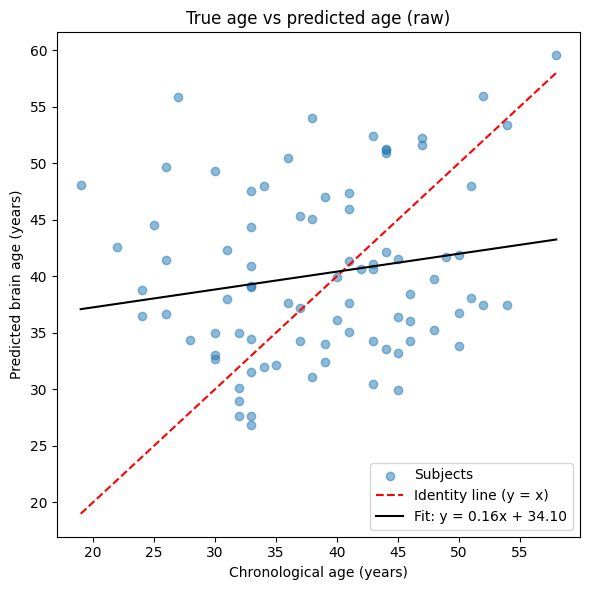

In [36]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5, label="Subjects")

# Identity line
x_line = np.linspace(y_true.min(), y_true.max(), 100)
plt.plot(x_line, x_line, "r--", label="Identity line (y = x)")

# Linear fit
coef = np.polyfit(y_true, y_pred, 1)
y_fit = coef[0] * x_line + coef[1]
plt.plot(x_line, y_fit, "k-", label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}")

plt.xlabel("Chronological age (years)")
plt.ylabel("Predicted brain age (years)")
plt.title("True age vs predicted age (raw)")
plt.legend()
plt.tight_layout()
plt.show()

### True age vs bias-corrected predicted age 

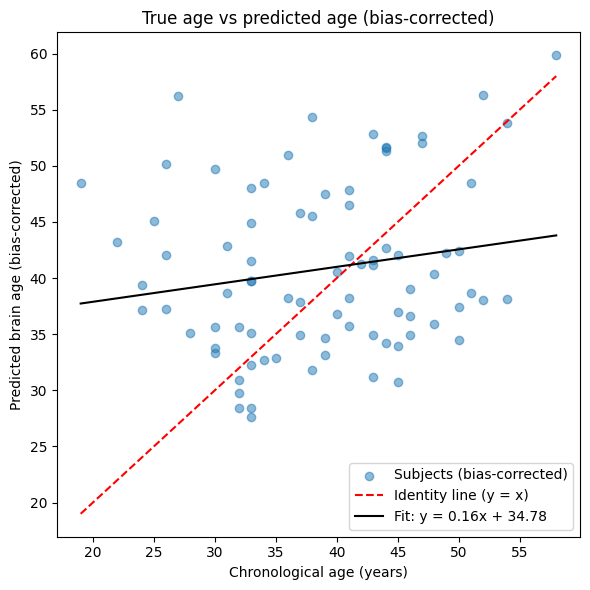

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred_bc, alpha=0.5, label="Subjects (bias-corrected)")

# Identity line
plt.plot(x_line, x_line, "r--", label="Identity line (y = x)")

# Linear fit after BC
coef_bc = np.polyfit(y_true, y_pred_bc, 1)
y_fit_bc = coef_bc[0] * x_line + coef_bc[1]
plt.plot(x_line, y_fit_bc, "k-", label=f"Fit: y = {coef_bc[0]:.2f}x + {coef_bc[1]:.2f}")

plt.xlabel("Chronological age (years)")
plt.ylabel("Predicted brain age (bias-corrected)")
plt.title("True age vs predicted age (bias-corrected)")
plt.legend()
plt.tight_layout()
plt.show()

### Brain age gap vs true age

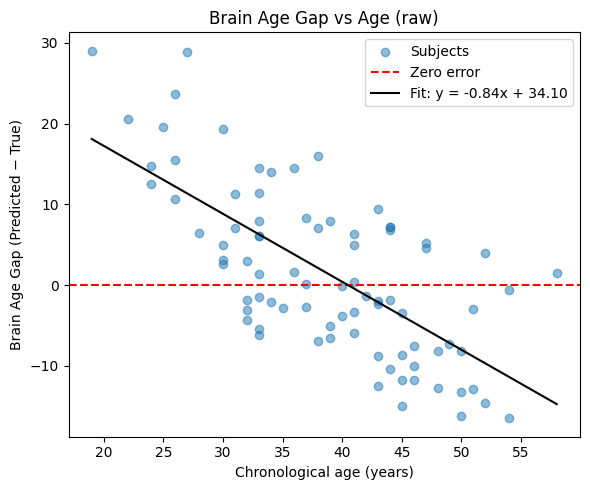

In [38]:
bag = y_pred - y_true

coef = np.polyfit(y_true, bag, 1)
y_fit = coef[0] * x_line + coef[1]

plt.figure(figsize=(6,5))
plt.scatter(y_true, bag, alpha=0.5, label="Subjects")

plt.axhline(0, color="red", linestyle="--", label="Zero error")
plt.plot(
    x_line, y_fit, 'k-',
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

plt.xlabel("Chronological age (years)")
plt.ylabel("Brain Age Gap (Predicted − True)")
plt.title("Brain Age Gap vs Age (raw)")
plt.legend()
plt.tight_layout()
plt.show()


### Brain age gap (bias-corrected) vs true age

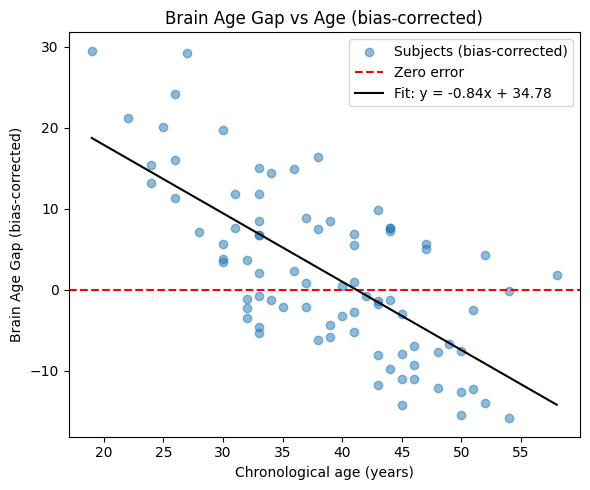

In [39]:
bag_bc = y_pred_bc - y_true

coef_bc = np.polyfit(y_true, bag_bc, 1)
y_fit_bc = coef_bc[0] * x_line + coef_bc[1]

plt.figure(figsize=(6,5))
plt.scatter(y_true, bag_bc, alpha=0.5, label="Subjects (bias-corrected)")

plt.axhline(0, color="red", linestyle="--", label="Zero error")
plt.plot(
    x_line, y_fit_bc, 'k-',
    label=f"Fit: y = {coef_bc[0]:.2f}x + {coef_bc[1]:.2f}"
)

plt.xlabel("Chronological age (years)")
plt.ylabel("Brain Age Gap (bias-corrected)")
plt.title("Brain Age Gap vs Age (bias-corrected)")
plt.legend()
plt.tight_layout()
plt.show()


### Histogram of brain age gap

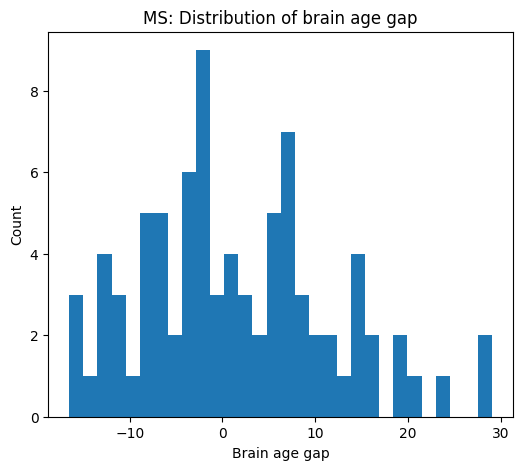

In [40]:
plt.figure(figsize=(6,5))
plt.hist(df_ms["brain_age_gap"], bins=30)
plt.xlabel("Brain age gap")
plt.ylabel("Count")
plt.title("MS: Distribution of brain age gap")
plt.show()

### Bland-Altman plot

Text(0, 0.5, 'Pred - True age')

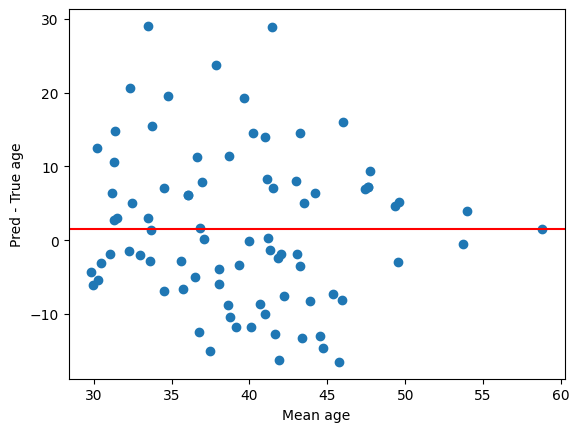

In [41]:
mean_age = (df_ms["predicted_age"] + df_ms["age_BL"]) / 2
diff = df_ms["predicted_age"] - df_ms["age_BL"]

plt.scatter(mean_age, diff)
plt.axhline(diff.mean(), color='red')
plt.xlabel("Mean age")
plt.ylabel("Pred - True age")

#shows systematic bias

### Brain age gap vs EDSS

In [42]:
df_edss = df_ms.dropna(subset=["EDSS_BL", "brain_age_gap"])
print(f"Subjects with EDSS: {len(df_edss)} / {len(df_ms)}")

Subjects with EDSS: 83 / 83


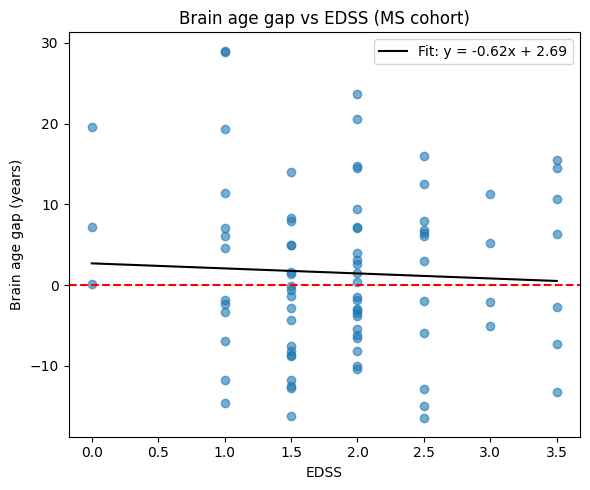

In [43]:
plt.figure(figsize=(6, 5))

# Scatter
plt.scatter(df_edss["EDSS_BL"], df_edss["brain_age_gap"], alpha=0.6)

# Horisontal null-linje
plt.axhline(0, color="red", linestyle="--")

# Lineær trend (kun på gyldige verdier)
coef = np.polyfit(df_edss["EDSS_BL"], df_edss["brain_age_gap"], 1)
x_line = np.linspace(df_edss["EDSS_BL"].min(), df_edss["EDSS_BL"].max(), 100)
y_line = coef[0] * x_line + coef[1]

plt.plot(
    x_line,
    y_line,
    color="black",
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

plt.xlabel("EDSS")
plt.ylabel("Brain age gap (years)")
plt.title("Brain age gap vs EDSS (MS cohort)")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
from scipy.stats import spearmanr

rho, pval = spearmanr(df_edss["EDSS_BL"], df_edss["brain_age_gap"])

print(f"Spearman r = {rho:.2f}, p = {pval:.4f}")

Spearman r = 0.00, p = 0.9709


### Brain age gap (corrected) vs EDSS

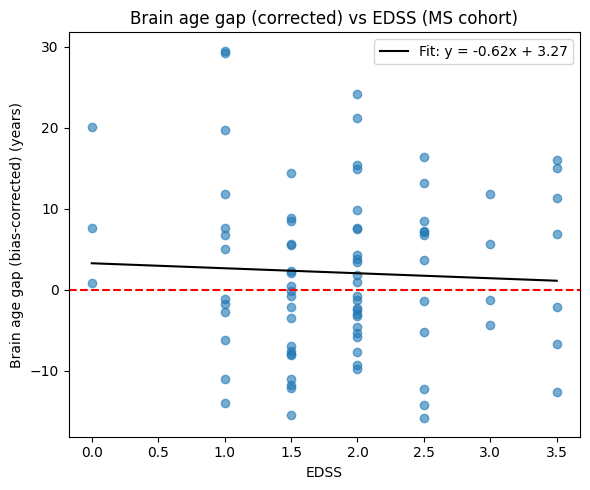

In [45]:
plt.figure(figsize=(6, 5))

# Scatter
plt.scatter(df_edss["EDSS_BL"], df_edss["brain_age_gap_bc"], alpha=0.6)

# Horisontal null-linje
plt.axhline(0, color="red", linestyle="--")

# Lineær trend (kun på gyldige verdier)
coef = np.polyfit(df_edss["EDSS_BL"], df_edss["brain_age_gap_bc"], 1)
x_line = np.linspace(df_edss["EDSS_BL"].min(), df_edss["EDSS_BL"].max(), 100)
y_line = coef[0] * x_line + coef[1]

plt.plot(
    x_line,
    y_line,
    color="black",
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

plt.xlabel("EDSS")
plt.ylabel("Brain age gap (bias-corrected) (years)")
plt.title("Brain age gap (corrected) vs EDSS (MS cohort)")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
from scipy.stats import spearmanr

rho, pval = spearmanr(df_edss["EDSS_BL"], df_edss["brain_age_gap_bc"])

print(f"Spearman r = {rho:.2f}, p = {pval:.4f}")

Spearman r = 0.01, p = 0.9617


### Brain age gap - gender distribution

<Figure size 600x500 with 0 Axes>

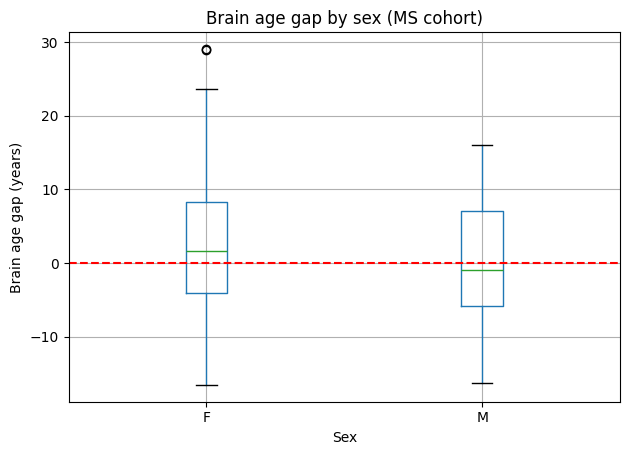

In [47]:
plt.figure(figsize=(6, 5))
df_ms.boxplot(column="brain_age_gap", by="sex")

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Sex")
plt.ylabel("Brain age gap (years)")
plt.title("Brain age gap by sex (MS cohort)")
plt.suptitle("")  # fjerner automatisk pandas-tittel
plt.tight_layout()
plt.show()

### Correlation: BAG vs EDSS (Pearson + Spearman)

In [48]:
import numpy as np
import pandas as pd
from scipy import stats

def corr_report(x, y, label_x="x", label_y="y"):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    r, p = stats.pearsonr(df["x"], df["y"])
    rho, p_s = stats.spearmanr(df["x"], df["y"])
    print(f"{label_y} vs {label_x} (n={len(df)}):")
    print(f"  Pearson r = {r:.3f}, p = {p:.3g}")
    print(f"  Spearman ρ = {rho:.3f}, p = {p_s:.3g}")

# Raw
corr_report(df_ms["EDSS_BL"], df_ms["brain_age_gap"], label_x="EDSS_BL", label_y="brain_age_gap")

# Bias-corrected (hvis du har)
if "brain_age_gap_bc" in df_ms.columns:
    corr_report(df_ms["EDSS_BL"], df_ms["brain_age_gap_bc"], label_x="EDSS", label_y="brain_age_gap_bc")

brain_age_gap vs EDSS_BL (n=83):
  Pearson r = -0.048, p = 0.667
  Spearman ρ = 0.004, p = 0.971
brain_age_gap_bc vs EDSS (n=83):
  Pearson r = -0.048, p = 0.668
  Spearman ρ = 0.005, p = 0.962


Conclusion: there is no connection between EDSS and BAG.

In [49]:
from scipy import stats

stats.pearsonr(df_ms["age_BL"], df_ms["brain_age_gap_bc"])

PearsonRResult(statistic=np.float64(-0.6963365993097665), pvalue=np.float64(2.693234269296754e-13))

Conclusion: A strong negative correlation was observed (r = -0.70, p < 0.001), indicating a highly significant inverse relationship between age and BAG (corrected).

### Linear regression: BAG = EDSS + age + sex

In [50]:
import statsmodels.formula.api as smf

# Velg hvilken BAG du vil analysere
bag_col = "brain_age_gap_bc" if "brain_age_gap_bc" in df_ms.columns else "brain_age_gap"

# Sørg for at sex er kategorisk (tilpass hvis sex er 0/1 eller 'M'/'F')
df_reg = df_ms.copy()
df_reg["sex"] = df_reg["sex"].astype("category")

model = smf.ols(f"{bag_col} ~ EDSS_BL + age_BL + sex", data=df_reg).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       brain_age_gap_bc   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     23.15
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.13e-10
Time:                        14:47:38   Log-Likelihood:                -265.59
No. Observations:                  78   AIC:                             539.2
Df Residuals:                      74   BIC:                             548.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.2145      4.460      8.120      0.0

In [51]:
model_rob = model.get_robustcov_results(cov_type="HC3")
print(model_rob.summary())

                            OLS Regression Results                            
Dep. Variable:       brain_age_gap_bc   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     17.06
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.62e-08
Time:                        14:47:38   Log-Likelihood:                -265.59
No. Observations:                  78   AIC:                             539.2
Df Residuals:                      74   BIC:                             548.6
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.2145      5.397      6.710      0.0

Observation: older people have smaller BAG. Why? Maybe residual bias in the model.

### Effect size: Cohen's d

#### Comparing male and female

In [52]:
def cohens_d(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2)) if (n1+n2-2) > 0 else np.nan
    return (a.mean() - b.mean()) / sp if sp and not np.isnan(sp) else np.nan

if df_ms["sex"].nunique() == 2:
    groups = list(df_ms["sex"].unique())
    g1, g2 = groups[0], groups[1]
    d = cohens_d(df_ms.loc[df_ms["sex"]==g1, bag_col], df_ms.loc[df_ms["sex"]==g2, bag_col])
    print(f"Cohen's d ({bag_col}) for sex {g1} vs {g2}: {d:.3f}")

Cohen's d (brain_age_gap_bc) for sex F vs M: 0.244


A small effect size was observed between females and males (Cohen’s d = 0.24), indicating slightly higher brain age gap values in females compared to males.

#### Comparing mild vs severe EDSS

In [53]:
# eksempel: EDSS < 3 vs >= 3 (tilpass terskel)
df_ms["edss_group"] = np.where(df_ms["EDSS_BL"] < 3, "mild", "severe")
d_edss = cohens_d(df_ms.loc[df_ms["edss_group"]=="mild", bag_col],
                  df_ms.loc[df_ms["edss_group"]=="severe", bag_col])
print(f"Cohen's d ({bag_col}) for EDSS mild vs severe: {d_edss:.3f}")

Cohen's d (brain_age_gap_bc) for EDSS mild vs severe: -0.167


### Residual BAG

In [54]:
[c for c in df_ms.columns if "gap" in c.lower() or "bag" in c.lower() or "pred" in c.lower()]

['predicted_age', 'brain_age_gap', 'predicted_age_bc', 'brain_age_gap_bc']

In [55]:
import numpy as np
import pandas as pd
from scipy import stats

bag_col = "brain_age_gap_bc" if "brain_age_gap_bc" in df_ms.columns else "brain_age_gap"

# Rens for NaN
tmp_age = df_ms[["age_BL", bag_col]].copy()
tmp_age["age_BL"] = pd.to_numeric(tmp_age["age_BL"], errors="coerce")
tmp_age[bag_col]  = pd.to_numeric(tmp_age[bag_col], errors="coerce")
tmp_age = tmp_age.replace([np.inf, -np.inf], np.nan).dropna()

# Fit BAG ~ age
slope, intercept, *_ = stats.linregress(tmp_age["age_BL"], tmp_age[bag_col])

# Lag residual i df_ms (bevarer NaN der input mangler)
df_ms["BAG_residual"] = pd.to_numeric(df_ms[bag_col], errors="coerce") - (slope * pd.to_numeric(df_ms["age_BL"], errors="coerce") + intercept)

print("Made BAG_residual. Pearson(age, residual) =",
      stats.pearsonr(tmp_age["age_BL"], (tmp_age[bag_col] - (slope*tmp_age["age_BL"] + intercept)) )
)

Made BAG_residual. Pearson(age, residual) = PearsonRResult(statistic=np.float64(-3.341562046926257e-16), pvalue=np.float64(0.9999999999999968))


Dette fjernet aldersavhengigheten fra BAG.

In [56]:
import numpy as np
from scipy import stats

tmp = df_ms[["EDSS_BL", "BAG_residual"]].copy()

tmp["EDSS_BL"] = pd.to_numeric(tmp["EDSS_BL"], errors="coerce")
tmp["BAG_residual"] = pd.to_numeric(tmp["BAG_residual"], errors="coerce")

tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

print("N after cleaning:", len(tmp))
print("EDSS unique values:", tmp["EDSS_BL"].nunique())
print("EDSS min/max:", tmp["EDSS_BL"].min(), tmp["EDSS_BL"].max())
print("BAG_residual std:", tmp["BAG_residual"].std())

if tmp["EDSS_BL"].nunique() > 1 and tmp["BAG_residual"].std() > 0:
    print("Pearson:", stats.pearsonr(tmp["EDSS_BL"], tmp["BAG_residual"]))
    print("Spearman:", stats.spearmanr(tmp["EDSS_BL"], tmp["BAG_residual"]))
else:
    print("Cannot compute correlation: EDSS_BL or BAG_residual has zero variance (or too few values).")

N after cleaning: 83
EDSS unique values: 7
EDSS min/max: 0.0 3.5
BAG_residual std: 7.374272408659796
Pearson: PearsonRResult(statistic=np.float64(-0.048182432377069095), pvalue=np.float64(0.6653365844385929))
Spearman: SignificanceResult(statistic=np.float64(-0.008873744285095842), pvalue=np.float64(0.9365401553712589))


In [57]:
stats.spearmanr(tmp["EDSS_BL"], tmp["BAG_residual"])

SignificanceResult(statistic=np.float64(-0.008873744285095842), pvalue=np.float64(0.9365401553712589))

No association was observed (Spearman ρ ≈ -0.01, p = 0.94), indicating no relationship between the variables.

In [58]:
from scipy import stats
stats.ttest_1samp(df_ms["BAG_residual"], 0)

TtestResult(statistic=np.float64(3.648808543349767e-15), pvalue=np.float64(0.9999999999999971), df=np.int64(82))

## Plots: Residual BAG

The brain age gap (BAG) is the difference between predicted brain age and chronological age. In our MS cohort, BAG still showed a strong dependence on age, meaning it partly reflected age-related trends rather than disease-related variation. We therefore computed a residual BAG by regressing BAG on age and using the residuals, which removes the age effect and isolates deviations from expected brain aging.

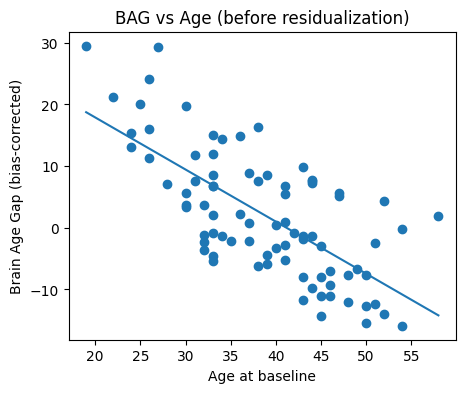

In [59]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,4))
plt.scatter(df_ms["age_BL"], df_ms["brain_age_gap_bc"])

m, b = np.polyfit(df_ms["age_BL"], df_ms["brain_age_gap_bc"], 1)
x = np.linspace(df_ms["age_BL"].min(), df_ms["age_BL"].max(), 100)
plt.plot(x, m*x + b)

plt.xlabel("Age at baseline")
plt.ylabel("Brain Age Gap (bias-corrected)")
plt.title("BAG vs Age (before residualization)")
plt.show()

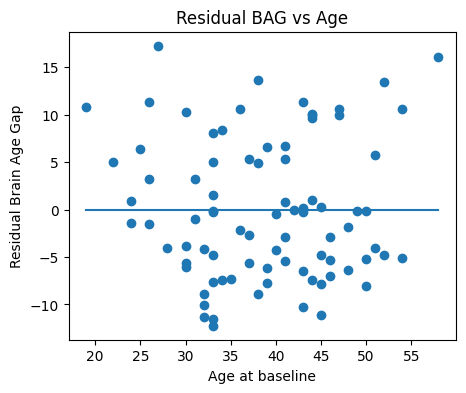

In [60]:
plt.figure(figsize=(5,4))
plt.scatter(df_ms["age_BL"], df_ms["BAG_residual"])

m, b = np.polyfit(df_ms["age_BL"], df_ms["BAG_residual"], 1)
x = np.linspace(df_ms["age_BL"].min(), df_ms["age_BL"].max(), 100)
plt.plot(x, m*x + b)

plt.xlabel("Age at baseline")
plt.ylabel("Residual Brain Age Gap")
plt.title("Residual BAG vs Age")
plt.show()

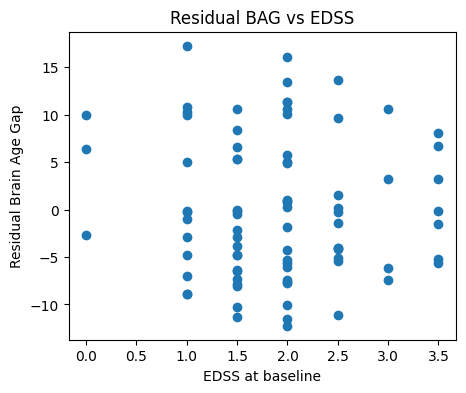

In [61]:
plt.figure(figsize=(5,4))
plt.scatter(df_ms["EDSS_BL"], df_ms["BAG_residual"])

plt.xlabel("EDSS at baseline")
plt.ylabel("Residual Brain Age Gap")
plt.title("Residual BAG vs EDSS")
plt.show()

Residual BAG is only for visualization, especially in combinaation with EDSS, but the initial predictions and BAG (also with bias correction) will be used further.

BAG var age-dependent, but residual BAG removed this. HOWEVER, BAG_residual and EDSS still show no dependence.

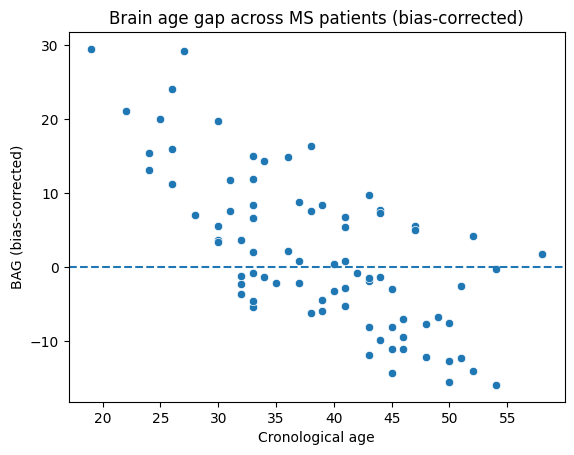

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="age_BL",
    y="brain_age_gap_bc",
    data=df_ms,
)

plt.axhline(0, linestyle="--")
plt.xlabel("Cronological age")
plt.ylabel("BAG (bias-corrected)")
plt.title("Brain age gap across MS patients (bias-corrected)")
plt.show()

In [63]:
df_ms.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/101/baseline/mri/step4_warped/sAI_mwrp1sub-101_ses-baseline_ce-GADOLINIUM_FLASH_affine.nii,101,F,35.0,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,-7.319295
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/103/baseline/mri/step4_warped/sAI_mwrp1sub-103_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,103,M,24.0,2.5,36.474022,12.474022,37.120201,13.120201,mild,-1.392804
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/104/baseline/mri/step4_warped/sAI_mwrp1sub-104_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,104,F,48.0,1.5,35.260303,-12.739697,35.924599,-12.075401,mild,-6.323716
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1101/baseline/mri/step4_warped/sAI_mwrp1sub-1101_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1101,F,46.0,2.0,36.009117,-9.990883,36.662235,-9.337765,mild,-5.274804
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/T1_scans/1102/baseline/mri/step4_warped/sAI_mwrp1sub-1102_ses-baseline_ce-GADOLINIUM_T1w_affine.nii,1102,F,39.0,1.5,46.991196,7.991196,47.480396,8.480396,mild,6.632822


## Save results

In [64]:
df_ms.to_csv("smoothed_MS_brain_age_predictions_baseline.csv", index=False)